In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. LOAD DATASET
# =====================================================================
df = pd.read_csv('supplier_risk_ok.csv')
print(f"Jumlah data : {df.shape[0]} baris, {df.shape[1]} kolom")
print("\nDistribusi kelas (Risk_Category):")
print(df['Risk_Category'].value_counts())
df.head()


Jumlah data : 2000 baris, 12 kolom

Distribusi kelas (Risk_Category):
Risk_Category
High    1169
Low      831
Name: count, dtype: int64


,Supplier_ID,Year,Financial_Stability_Score,Delivery_Performance_Score,Quality_Compliance_Score,Regulatory_Adherence_Score,Sustainability_Score,Past_Risk_Level,ERP_Transactions,Incidents_Count,MCDM_Score,Risk_Category
0,16,2023,0.6639,0.4676,0.5966,0.5029,0.4339,0.2800,401,3,0.6088,Low
1,68,2024,0.1210,0.6171,0.4109,0.5461,0.5319,0.7504,161,7,0.5133,High
2,22,2022,0.5452,0.4857,0.5622,1.0000,0.4119,0.5513,276,1,0.6532,Low
3,14,2021,0.6257,0.6288,0.6581,0.5937,0.4079,0.3226,392,4,0.7943,Low
4,41,2025,0.6644,0.9072,0.7373,0.5378,0.6598,0.2073,332,1,0.6573,Low


In [2]:
# =====================================================================
# 2. SELEKSI FITUR & ENCODING TARGET
# =====================================================================
# Kolom yang DIBUANG:
#   - Supplier_ID -> hanya identitas, tidak prediktif
#   - Year        -> tahun, bukan faktor risiko
# Sisanya dipakai sebagai fitur (semua numerik, korelasi 0.38 - 0.59).

drop_cols = ['Supplier_ID', 'Year', 'Risk_Category']
manual_features = [c for c in df.columns if c not in drop_cols]

target = 'Risk_Category'
# Encode target -> High = 1 (risiko yang ingin dideteksi), Low = 0
df['target'] = (df[target] == 'High').astype(int)

X = df[manual_features]
y = df['target']

print(f"Jumlah fitur dipakai : {len(manual_features)}")
print("Fitur :", manual_features)
print("Mapping target -> High=1, Low=0")


Jumlah fitur dipakai : 9
Fitur : ['Financial_Stability_Score', 'Delivery_Performance_Score', 'Quality_Compliance_Score', 'Regulatory_Adherence_Score', 'Sustainability_Score', 'Past_Risk_Level', 'ERP_Transactions', 'Incidents_Count', 'MCDM_Score']
Mapping target -> High=1, Low=0


In [3]:
# =====================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
print("Rata-rata fitur per kelas:")
print(df.groupby(target)[manual_features].mean().T.round(3))

# Outlier hanya DIDETEKSI untuk analisis, TIDAK dihapus, karena mayoritas
# outlier adalah pemasok High-risk yang valid (relevan untuk deteksi dini).
# XGBoost juga tahan terhadap outlier karena berbasis pohon (split).

print("\nJumlah outlier per fitur (metode IQR):")
total_mask = pd.Series(False, index=df.index)
for c in manual_features:
    q1, q3 = df[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[c] < lo) | (df[c] > hi)
    total_mask |= mask
    print(f"  {c:30s}: {mask.sum():>3} outlier ({100*mask.sum()/len(df):.1f}%)")

print(f"\nTotal baris dengan >=1 outlier : {total_mask.sum()} ({100*total_mask.sum()/len(df):.1f}%)")
print(f"Proporsi High pada baris outlier: {100*(df['target'][total_mask]).mean():.1f}%")
print(f"Proporsi High pada baris normal : {100*(df['target'][~total_mask]).mean():.1f}%")
print("\n=> Kesimpulan: outlier DIPERTAHANKAN karena mayoritas merupakan")
print("   pemasok High-risk yang valid dan relevan untuk sistem peringatan dini.")

Rata-rata fitur per kelas:
Risk_Category                  High      Low
Financial_Stability_Score     0.387    0.581
Delivery_Performance_Score    0.456    0.649
Quality_Compliance_Score      0.417    0.616
Regulatory_Adherence_Score    0.519    0.677
Sustainability_Score          0.429    0.547
Past_Risk_Level               0.606    0.369
ERP_Transactions            251.390  321.129
Incidents_Count               5.853    2.084
MCDM_Score                    0.517    0.638

Jumlah outlier per fitur (metode IQR):
  Financial_Stability_Score     :   0 outlier (0.0%)
  Delivery_Performance_Score    :   0 outlier (0.0%)
  Quality_Compliance_Score      :   3 outlier (0.1%)
  Regulatory_Adherence_Score    :   5 outlier (0.2%)
  Sustainability_Score          :  19 outlier (0.9%)
  Past_Risk_Level               :   0 outlier (0.0%)
  ERP_Transactions              :   6 outlier (0.3%)
  Incidents_Count               :  25 outlier (1.2%)
  MCDM_Score                    :   2 outlier (0.1%)

Total

In [4]:
# =====================================================================
# 4. SPLIT DATA (TRAIN 80% - TEST 20%)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing  : {X_test.shape[0]} baris")
print("\nDistribusi kelas (training):", dict(y_train.value_counts()))


Data Training : 1600 baris
Data Testing  : 400 baris

Distribusi kelas (training): {1: np.int64(935), 0: np.int64(665)}


In [5]:
# =====================================================================
# 5. XGBOOST + HYPERPARAMETER TUNING (GridSearchCV)
# =====================================================================
# Tangani sedikit imbalance: scale_pos_weight = jumlah kelas 0 / kelas 1
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

model_xgb = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

param_grid = {
    'max_depth': [3, 4],          # turunkan dari [3,5] -> pohon lebih dangkal
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda': [1, 5, 10],     # TAMBAH regularisasi (penalti agar tak hafal)
    'min_child_weight': [1, 5],   # TAMBAH (cegah split terlalu spesifik)

}

# scoring='f1' menyeimbangkan precision & recall.
grid_search = GridSearchCV(model_xgb, param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
print("Melatih model (mencari parameter terbaik)...")
grid_search.fit(X_train, y_train)
print("\nParameter terbaik:", grid_search.best_params_)


Melatih model (mencari parameter terbaik)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits



Parameter terbaik: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 100, 'reg_lambda': 5, 'subsample': 0.8}


     ANALISIS OVERFITTING & UNDERFITTING
Akurasi Training : 0.9313
Akurasi Testing  : 0.8925
----------------------------------------------
F1-score Testing : 0.9091
Recall Testing   : 0.9188
AUC Testing      : 0.9640

Classification Report (Testing):
              precision    recall  f1-score   support

         Low       0.88      0.86      0.87       166
        High       0.90      0.92      0.91       234

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



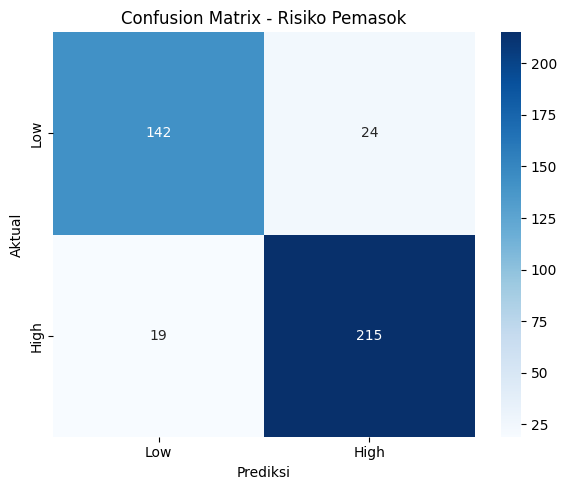

In [6]:
# =====================================================================
# 6. EVALUASI MODEL & CONFUSION MATRIX
# =====================================================================
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("==============================================")
print("     ANALISIS OVERFITTING & UNDERFITTING")
print("==============================================")
print(f"Akurasi Training : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Akurasi Testing  : {accuracy_score(y_test, y_test_pred):.4f}")
print("-"*46)
print(f"F1-score Testing : {f1_score(y_test, y_test_pred):.4f}")
print(f"Recall Testing   : {recall_score(y_test, y_test_pred):.4f}")
print(f"AUC Testing      : {roc_auc_score(y_test, y_test_proba):.4f}")
print("==============================================\n")
print("Classification Report (Testing):")
print(classification_report(y_test, y_test_pred, target_names=['Low', 'High']))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.title('Confusion Matrix - Risiko Pemasok')
plt.tight_layout(); plt.show()


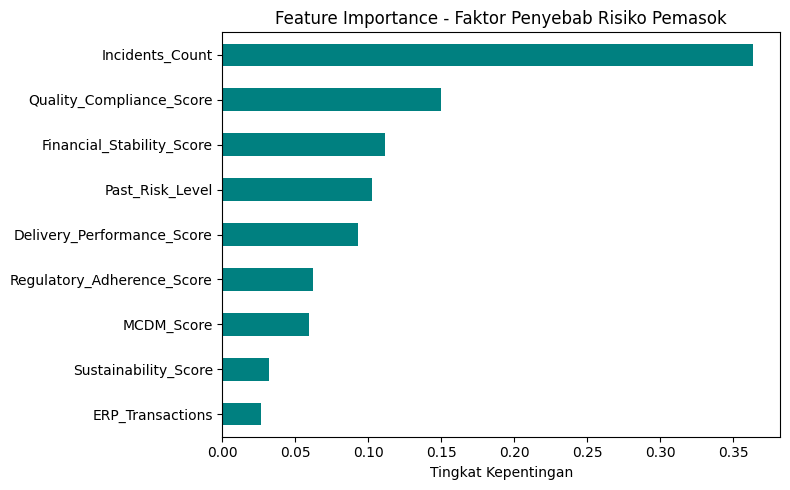

Incidents_Count               0.3639
Quality_Compliance_Score      0.1499
Financial_Stability_Score     0.1113
Past_Risk_Level               0.1022
Delivery_Performance_Score    0.0931
Regulatory_Adherence_Score    0.0620
MCDM_Score                    0.0596
Sustainability_Score          0.0318
ERP_Transactions              0.0263
dtype: float32


In [7]:
# =====================================================================
# 7. FEATURE IMPORTANCE (faktor penyebab risiko utama)
# =====================================================================
importances = pd.Series(best_model.feature_importances_, index=manual_features).sort_values()
plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance - Faktor Penyebab Risiko Pemasok')
plt.xlabel('Tingkat Kepentingan'); plt.tight_layout(); plt.show()
print(importances.sort_values(ascending=False).round(4))


In [8]:
import joblib
# Menyimpan model terbaik ke file pickle
joblib.dump(best_model, 'model_xgb_9fitur.pkl')
print('Model berhasil disimpan sebagai model_xgb_9fitur.pkl!')

Model berhasil disimpan sebagai model_xgb_9fitur.pkl!
